In [1]:
!pip install seaborn
!pip install pydicom scikit-image networkx matplotlib numpy scipy
!pip install scikit-image
!pip install openpyxl
!pip install SimpleITK

import os
import SimpleITK as sitk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#from google.colab import drive
from skimage.morphology import skeletonize
from skimage.morphology import remove_small_holes
from skimage import img_as_bool
from scipy.spatial import KDTree
from scipy.ndimage import label
from scipy.ndimage import center_of_mass
import seaborn as sns
from sklearn.cluster import KMeans
import pydicom
from skimage import filters, morphology, measure
from scipy.ndimage import gaussian_filter, binary_closing
import networkx as nx
from skimage.graph import MCP_Geometric
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

import skimage
print("scikit-image version:", skimage.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 21.2 MB/s eta 0:00:00
scikit-image version: 0.25.2


In [2]:
from google.colab import drive
!pip install -q gdown
import gdown
!apt-get install unrar -y

# "https://drive.google.com/file/d/1M9Lt6Ivhqccernc42qo-MvgifkNHcJjo/view?usp=sharing"

drive.mount('/content/drive')
file_id = "1M9Lt6Ivhqccernc42qo-MvgifkNHcJjo"
url = f"https://drive.google.com/uc?export=download&id={file_id}"


gdown.download(url, "file.rar", quiet=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1M9Lt6Ivhqccernc42qo-MvgifkNHcJjo
From (redirected): https://drive.google.com/uc?export=download&id=1M9Lt6Ivhqccernc42qo-MvgifkNHcJjo&confirm=t&uuid=0a7f1ad6-7cea-4984-9539-3ee047e13315
To: /content/file.rar
100%|██████████| 585M/585M [00:02<00:00, 196MB/s]


'file.rar'

In [3]:
!unrar x file.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from file.rar

Creating    Data                                                      OK
Creating    Data/1100702199                                           OK
Extracting  Data/1100702199/Autorun.exe                                    0%  OK 
Extracting  Data/1100702199/autorun.inf                                    0%  OK 
Creating    Data/1100702199/CDViewer                                  OK
Extracting  Data/1100702199/CDViewer/AES.dll                               0%  OK 
Extracting  Data/1100702199/CDViewer/CDViewer.exe                          0%  OK 
Extracting  Data/1100702199/CDViewer/dcmtk.dll                             0%  OK 
Extracting  Data/1100702199/CDViewer/dcmtkeay.dll                          0%  OK 
Extracting  Data/1100702199/CDViewer/dcmtkssl.dll                          0%  OK 
Extracting  Data/1100702199/CDViewe

Files in input_path: ['00000028', '00000036', '00000027', '00000023', '00000014', '00000029', '00000004', '00000010', '00000005', '00000025', '00000034', '00000031', '00000037', '00000013', '00000001', '00000011', '00000002', '00000015', '00000022', '00000020', '00000033', '00000019', '00000021', '00000032', '00000009', '00000030', '00000024', '00000026', '00000008', '00000018', '00000007', '00000006', '00000035', '00000016', '00000003', '00000012', '00000017']
Image size: (1017, 1017, 37)
Image spacing: (1.0, 1.0, 1.0)
Pixel type of input image: vector of 8-bit unsigned integer


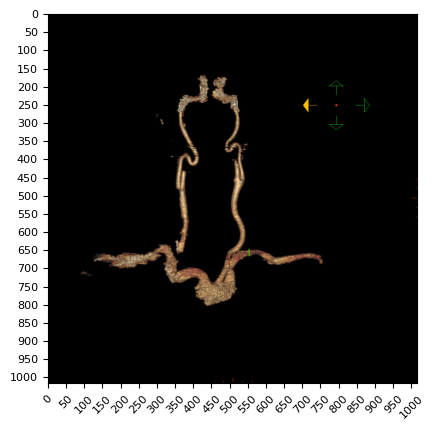

Image size after resampling: (1017, 1017, 37)


In [4]:
input_path = "/content/Data/1170927769/DICOM/20250531/223757"
input_path = input_path
output_path = "/content/output"

os.makedirs(output_path, exist_ok=True)

if os.path.exists(input_path):
    print("Files in input_path:", os.listdir(input_path))
else:
    raise FileNotFoundError(f"Input directory {input_path} does not exist.")

reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(input_path)
if not dicom_names:
    raise FileNotFoundError("No DICOM files found in the directory.")
reader.SetFileNames(dicom_names)
img = reader.Execute()
img_array = sitk.GetArrayFromImage(img)
print("Image size:", img.GetSize())
print("Image spacing:", img.GetSpacing())
print("Pixel type of input image:", img.GetPixelIDTypeAsString())

plt.imshow(img_array[0, :, :], cmap='gray')
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.tick_params(axis='x', labelsize=8, labelrotation=45)
ax.tick_params(axis='y', labelsize=8)
plt.show()

def ensure_minimum_size(image, min_size=4):
    size = image.GetSize()
    spacing = image.GetSpacing()
    new_size = [max(s, min_size) for s in size]
    if size == tuple(new_size):
        return image
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(spacing)
    resampler.SetSize(new_size)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetOutputOrigin(image.GetOrigin())
    resampler.SetOutputDirection(image.GetDirection())
    return resampler.Execute(image)

img = ensure_minimum_size(img)
img_array = sitk.GetArrayFromImage(img)
print("Image size after resampling:", img.GetSize())

In [5]:
print("Pixel type before processing:", img.GetPixelIDTypeAsString())
if img.GetNumberOfComponentsPerPixel() > 1:
    print("Converting multi-component image to single-component.")
    img = sitk.VectorMagnitude(img)
img = sitk.Cast(img, sitk.sitkFloat32)
print("Pixel type after cast:", img.GetPixelIDTypeAsString())

enhanced_img=img

otsu_filter = sitk.OtsuThresholdImageFilter()
otsu_filter.SetInsideValue(0)
otsu_filter.SetOutsideValue(1)
binary_img = otsu_filter.Execute(enhanced_img)

Pixel type before processing: vector of 8-bit unsigned integer
Converting multi-component image to single-component.
Pixel type after cast: 32-bit float


In [6]:
kernel_radius = 2
binary_img = sitk.BinaryMorphologicalClosing(binary_img, [kernel_radius]*3)
connected_filter = sitk.ConnectedComponentImageFilter()
labeled_img = connected_filter.Execute(binary_img)
stats_filter = sitk.LabelShapeStatisticsImageFilter()
stats_filter.Execute(labeled_img)

labels = stats_filter.GetLabels()
sizes = [stats_filter.GetNumberOfPixels(l) for l in labels]
largest_label = labels[np.argmax(sizes)]
refined_img = (labeled_img == largest_label)

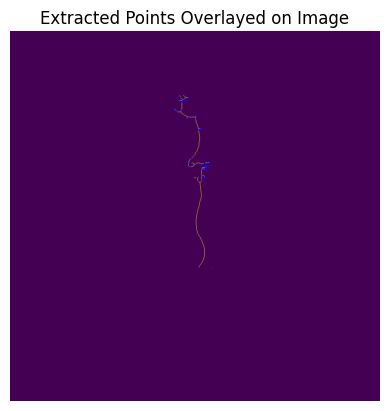

In [7]:
refined_array = sitk.GetArrayFromImage(refined_img)

bw = img_as_bool(refined_array*255)
out=remove_small_holes(bw, 140)

depth, height, width = bw.shape
skeleton_3d = np.zeros_like(bw, dtype=bool)
for i in range(depth):
    skeleton_3d[i] = skeletonize(out[i])

skeleton_array=skeleton_3d
skeleton_img = sitk.GetImageFromArray(skeleton_array.astype(np.uint8))
skeleton_img.CopyInformation(img)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

def turning_angles(points):
    """
    points: (N,2) ordered polyline
    returns:
      angles: (N-1,) angle of each segment in radians (atan2)
      dangles: (N-2,) signed turning angle between consecutive segments (radians, wrapped to (-pi,pi])
      seg_lengths: (N-1,) euclidean lengths of segments
    """
    pts = np.asarray(points, dtype=float)
    diffs = np.diff(pts, axis=0)               # (N-1,2)
    seg_lengths = np.linalg.norm(diffs, axis=1)
    angles = np.arctan2(diffs[:,1], diffs[:,0])  # (N-1,)
    # angle differences between consecutive segments
    raw = np.diff(angles)                        # (N-2,)
    # wrap to (-pi, pi]
    dangles = (raw + np.pi) % (2*np.pi) - np.pi
    return angles, dangles, seg_lengths

def find_turns(points, sigma=0.0, deg_threshold=20.0, min_distance=1):
    """
    Detect turning points in an ordered polyline.
    - sigma: gaussian smoothing applied to angles (0=no smoothing)
    - deg_threshold: turning threshold in degrees (absolute)
    - min_distance: minimum peak distance in number of turning-angle samples
    Returns: indices of points (in original points array) considered turning points.
      Note: turning angles are defined for interior points p[1..N-2].
    """
    angles, dangles, seg_lengths = turning_angles(points)
    # optional smoothing (on angles before differencing or on dangles)
    # if sigma > 0:
    #     # smooth angles then recompute dangles to avoid wrap problems use sin/cos smoothing instead
    #     a = angles
    #     # smooth sin and cos separately to preserve circular nature
    #     s = gaussian_filter1d(np.sin(a), sigma)
    #     c = gaussian_filter1d(np.cos(a), sigma)
    #     a_smooth = np.arctan2(s, c)
    #     dangles = np.diff(a_smooth)
    #     dangles = (dangles + np.pi) % (2*np.pi) - np.pi


    # curvature-like measure: absolute turning per unit length (optional)
    # use average of adjacent segment lengths to scale
    avg_len = (seg_lengths[:-1] + seg_lengths[1:]) / 2.0
    curvature = np.abs(dangles) / (avg_len + 1e-12)  # avoid div by zero

    # choose detection method: threshold on absolute angle or on curvature
    degs = np.degrees(np.abs(dangles))
    # primary candidates: where angle exceeds threshold
    cand_mask = degs >= deg_threshold

    # refine using peaks on degs or curvature
    peaks, props = find_peaks(degs, distance=min_distance, height=deg_threshold)
    # peaks array indexes into dangles (i.e. interior points corresponding to original index = peaks+1)
    # convert to indices in original points array: turning at point i corresponds to original point index = i+1
    turning_point_indices = (peaks + 1).tolist()  # interior points
    return {
        'angles': angles,
        'dangles': dangles,
        'deg_abs': degs,
        'curvature': curvature,
        'candidates_mask': cand_mask,
        'turning_point_indices': turning_point_indices
    }

#%%
# image=np.zeros([1017,1017],np.uint8)
# image[:650,450:]=skeleton_array[0,:650,450:]
# pts=np.argwhere(image)

#%%
# Make image canvas based on actual skeleton slice size (safe)
slice0 = skeleton_array[0]            # (H, W)
H, W = slice0.shape
# Option A: use exact same size
image = np.zeros((H, W), dtype=np.uint8)
r_end = min(650, H)
c_start = 450
# ensure c_start < W
if c_start >= W:

    c_start = 0
image[:r_end, c_start:] = slice0[:r_end, c_start:].astype(np.uint8)
pts = np.argwhere(image)


res = find_turns(pts, sigma=0.0, deg_threshold=49.5, min_distance=1)
turns = res['turning_point_indices']  # indices in pts of turning points
points=pts[turns]

fig, ax = plt.subplots()

# Show image on the axis
ax.imshow(image)

# Plot points over the same axis
x_coords = [p[0] for p in points]
y_coords = [p[1] for p in points]

ax.scatter(y_coords, x_coords, color='blue', s=0.1, marker='o')

ax.set_title("Extracted Points Overlayed on Image")
ax.axis("off")
plt.show()
#%%